In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Load the preprocessed data

In [ ]:
# Define the path to the preprocessed CSV file
input_path = "/content/LungCancer_Preprocessed_DataSet.csv"

# Load the preprocessed data into a DataFrame
df_preprocessed = pd.read_csv(input_path)

# Display the shape of the loaded DataFrame
print("Shape of the preprocessed DataFrame:")
print(df_preprocessed.shape)


Shape of the preprocessed DataFrame:
(100211, 36)


**Data Balancing and Feature Scaling**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold

# Data loading
df = pd.read_csv('/content/LungCancer_Preprocessed_DataSet.csv')

# Feature and target separation
X = df.drop(columns=['id', 'diagnosis_date', 'end_treatment_date', 'survived', 'family_history'])
y = df['survived']

# convert x to integer type
X = X.astype(int)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets (using stratified split is recommended for imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# Convert y to numpy arrays for easier indexing
y_train = np.array(y_train)
y_test = np.array(y_test)

# Undersample majority class (assuming 0 is majority, 1 is minority) to speed up training
minority_idx = np.where(y_train == 1)[0]
majority_idx = np.where(y_train == 0)[0]

# Calculates minority class
n_minority = len(minority_idx)
if n_minority == 0:
    raise ValueError("No minority class samples in training data.")
sampled_majority_idx = np.random.choice(majority_idx, n_minority, replace=False)
balanced_idx = np.hstack((sampled_majority_idx, minority_idx))

# Creates the balanced training data
X_train_bal = X_train[balanced_idx]
y_train_bal = y_train[balanced_idx]
print("Balanced training shape:", X_train_bal.shape)


Balanced training shape: (30908, 31)


##Modified Linear SVM

In [ ]:
# Scale the features (critical for SVM convergence and speed)
from sklearn.svm import LinearSVC
import time

# Creates a scaler object
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Modified Linear SVM (fast alternative to RBF for large data)
baseline_svm = LinearSVC(
    C=1.0,
    class_weight='balanced',
    dual=False,
    max_iter=10000,
    random_state=42
)

# Calculate training duration
start_time = time.time()
baseline_svm.fit(X_train_scaled, y_train)
fit_time = time.time() - start_time
print(f"Fit time: {fit_time:.4f} seconds")

# Predict and Evaluate Baseline Model
y_pred_baseline = baseline_svm.predict(X_test_scaled)
print("--- Baseline SVM Model Performance (with Class Weighting) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_baseline):.4f}")
print(classification_report(y_test, y_pred_baseline))

Fit time: 0.2715 seconds
--- Baseline SVM Model Performance (with Class Weighting) ---
Accuracy: 0.4970
              precision    recall  f1-score   support

           0       0.79      0.49      0.60     23440
           1       0.23      0.53      0.32      6624

    accuracy                           0.50     30064
   macro avg       0.51      0.51      0.46     30064
weighted avg       0.66      0.50      0.54     30064



**Hyperparameter tuning (RandomizedSearchCV)**

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score
import time
import numpy as np

# --- 3. Hyperparameter Tuning using RandomizedSearchCV ---

# Tuned Models
param_dist = {
    'C': [0.1, 1, 10],
}

# Stratified K-Fold Cross-Validation
# Validation method inside RandomizedSearchCV
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Initialize RandomizedSearchCV (faster than GridSearchCV)
random_search = RandomizedSearchCV(
    estimator=LinearSVC(
        class_weight='balanced',
        dual=False,
        max_iter=10000,
        random_state=42
        ),
    param_distributions=param_dist,
    n_iter=3,
    scoring='f1',
    cv=cv_strategy,
    verbose=2,
    n_jobs=-1
)

# Time the grid search
print("\n--- Starting RandomizedSearchCV for Hyperparameter Optimization ---")
start_time = time.time()
random_search.fit(X_train_scaled, y_train)
fit_time = time.time() - start_time

# Store the best model and parameters
best_svm = random_search.best_estimator_
best_params = random_search.best_params_
best_score = random_search.best_score_

# Print results
print("\n--- Optimized Model Results ---")
print(f"Fit time: {fit_time:.4f} seconds")
print("Best Hyperparameters:", best_params)
print(f"Best Cross-Validated F1-Score: {best_score:.4f}")

# Optional: Evaluate on test set
y_pred_best = best_svm.predict(X_test_scaled)
print(f"Test F1-Score: {f1_score(y_test, y_pred_best):.4f}")


--- Starting RandomizedSearchCV for Hyperparameter Optimization ---
Fitting 3 folds for each of 3 candidates, totalling 9 fits

--- Optimized Model Results ---
Fit time: 4.1506 seconds
Best Hyperparameters: {'C': 0.1}
Best Cross-Validated F1-Score: 0.3090
Test F1-Score: 0.3160


**Evaluate The Model**

In [ ]:
# --- 4. Evaluate Best Model on Test Set ---
y_pred_best = best_svm.predict(X_test)

print("\n--- Optimized SVM Model Performance on Final Test Set ---")
print(classification_report(y_test, y_pred_best))

# Detailed output
print("\nConfusion Matrix (Test Set):")
cm = confusion_matrix(y_test, y_pred_best)
print(cm)
print(f"\nFinal F1-Score: {f1_score(y_test, y_pred_best):.4f}")




--- Optimized SVM Model Performance on Final Test Set ---
              precision    recall  f1-score   support

           0       0.79      0.49      0.60     23440
           1       0.23      0.53      0.32      6624

    accuracy                           0.50     30064
   macro avg       0.51      0.51      0.46     30064
weighted avg       0.66      0.50      0.54     30064


Confusion Matrix (Test Set):
[[11443 11997]
 [ 3129  3495]]

Final F1-Score: 0.3161


**Confusion Matrix Visualization**

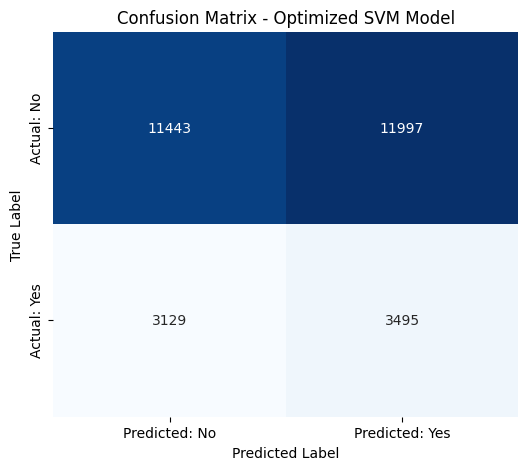

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Confusion Matrix Visualization ---

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Create a heatmap for visualization
plt.figure(figsize=(6, 5))  # Set the figure size
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])

# Add labels and title
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Optimized SVM Model')

# Show the heatmap
plt.show()


**Model Performance Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


y_true = y_test
y_pred = y_pred_best

# Example usage if you already have y_true and y_pred:
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='binary')   # pos class (1) precision
rec = recall_score(y_true, y_pred, average='binary')       # pos class (1) recall
f1 = f1_score(y_true, y_pred, average='binary')

# Print formatted like the image (4 decimal places)
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")

# If you want macro / weighted averages instead, use:
print("\nMacro averages:")
print(f"Precision (macro): {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"Recall    (macro): {recall_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1 Score  (macro): {f1_score(y_true, y_pred, average='macro'):.4f}")

print("\nWeighted averages:")
print(f"Precision (weighted): {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall    (weighted): {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 Score  (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")

Accuracy: 0.4969
Precision: 0.2256
Recall: 0.5276
F1 Score: 0.3161

Macro averages:
Precision (macro): 0.5054
Recall    (macro): 0.5079
F1 Score  (macro): 0.4591

Weighted averages:
Precision (weighted): 0.6620
Recall    (weighted): 0.4969
F1 Score  (weighted): 0.5391
